# [LAB 04] 데이터 다루기 - 11. 이상치 처리  

## #01. 준비 작업 

In [1]:
!pip install --upgrade matplotlib

   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------- ----------------------------- 2.4/9.3 MB 12.4 MB/s eta 0:00:01
   -------------------- ------------------- 4.7/9.3 MB 11.4 MB/s eta 0:00:01
   ------------------------------- -------- 7.3/9.3 MB 11.7 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 11.5 MB/s  0:00:00
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.9
    Uninstalling matplotlib-3.10.9:
      Successfully uninstalled matplotlib-3.10.9



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### 2. 라이브러리 참조 

In [2]:
import numpy as np
from jussam import load_data
from pandas import DataFrame 
from pandas import DataFrame
from sklearn.impute import SimpleImputer
from matplotlib import pyplot as plt

Matplotlib is building the font cache; this may take a moment.


### 3. 데이터 가져오기 

In [4]:
origin = load_data("ref_sample")
origin

📚 데이터 정제를 위한 실습용 데이터


,kor,eng,math,sic
name,,,,
철수,98.000,77,88.000,64.000
영희,88.000,120,62.000,72.000
민철,NaN,70,83.000,79.000
수현,63.000,60,31.000,71.000
호영,75.000,50,90.000,NaN
영호,80.000,88,91.000,72.000
용식,82.000,88,NaN,90.000
나영,90.000,92,81.000,NaN
석영,91.000,90,89.000,80.000


## #02. 결측치 정제하기 

### 1. 결측치를 평균으로 대체 

In [6]:
imr = SimpleImputer(missing_values = np.nan, strategy='mean')
df_imr = imr.fit_transform(origin.values)
re_df = DataFrame(df_imr, index= origin.index, columns=origin.columns)
re_df

,kor,eng,math,sic
name,,,,
철수,98.000,77.000,88.000,64.000
영희,88.000,120.000,62.000,72.000
민철,83.375,70.000,83.000,79.000
수현,63.000,60.000,31.000,71.000
호영,75.000,50.000,90.000,75.429
영호,80.000,88.000,91.000,72.000
용식,82.000,88.000,76.875,90.000
나영,90.000,92.000,81.000,75.429
석영,91.000,90.000,89.000,80.000


## #03. 이상치가 존재하는 변수 확인 

### 1. 상자그림 확인하기 

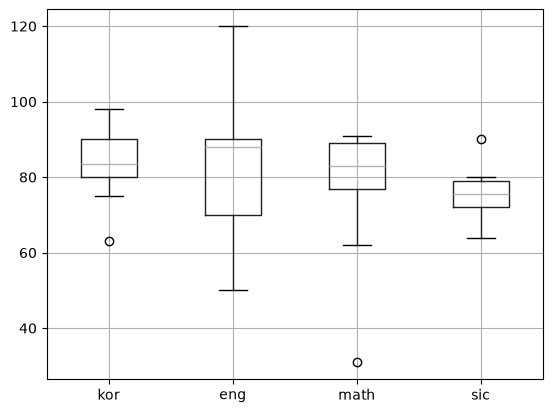

In [7]:
re_df.boxplot()
plt.show()

## #04. 분석가의 주관에 의한 이상치 판별 

### 2. 이상치를 결측치로 변경 

In [8]:
re_df.loc[re_df['eng']>100, 'eng'] = np.nan
re_df

,kor,eng,math,sic
name,,,,
철수,98.000,77.000,88.000,64.000
영희,88.000,NaN,62.000,72.000
민철,83.375,70.000,83.000,79.000
수현,63.000,60.000,31.000,71.000
호영,75.000,50.000,90.000,75.429
영호,80.000,88.000,91.000,72.000
용식,82.000,88.000,76.875,90.000
나영,90.000,92.000,81.000,75.429
석영,91.000,90.000,89.000,80.000


### 3. 변경된 결측지에 대한 처리 

In [10]:
imr = SimpleImputer(missing_values=np.nan, strategy='mean')
df_imr = imr.fit_transform(re_df.values)
outline_df = DataFrame(df_imr, index=re_df.index, columns=re_df.columns)
outline_df

,kor,eng,math,sic
name,,,,
철수,98.000,77.000,88.000,64.000
영희,88.000,76.875,62.000,72.000
민철,83.375,70.000,83.000,79.000
수현,63.000,60.000,31.000,71.000
호영,75.000,50.000,90.000,75.429
영호,80.000,88.000,91.000,72.000
용식,82.000,88.000,76.875,90.000
나영,90.000,92.000,81.000,75.429
석영,91.000,90.000,89.000,80.000


## #05. 극단치 경계값을 계산하여 이상치 찾기 

### 1. 사분위간 범위 계산 

In [11]:
outline_df2 = outline_df.copy()
국어Q1 = outline_df['kor'].quantile(0.25)
국어Q3 = outline_df['kor'].quantile(0.75)
국어iqr = 국어Q3 - 국어Q1 
print("국어 점수의 사분위간 범위:", 국어iqr)


국어 점수의 사분위간 범위: 10.0


### 2. 극단치 경계값 찾기 

In [12]:
outline_max = 국어Q3 + 국어iqr*1.5
outline_min = 국어Q3 - 국어iqr*1.5
print("상한 극단치 경계:", outline_max)
print("하한 극단치 경계:", outline_min)


상한 극단치 경계: 105.0
하한 극단치 경계: 75.0


### 3. 극단치 경계값을 활용하여 국어 점수에 대한 하한 이상치 확인 

In [13]:
outline_df2.loc[outline_df2['kor'] < outline_min, 'kor']


name
수현   63.000
Name: kor, dtype: float64

### 4. 국어 점수에 대한 하한 이상치를 결측치로 변환 

In [14]:
outline_df2.loc[outline_df['kor'] < outline_min, 'kor'] = np.nan
outline_df2

,kor,eng,math,sic
name,,,,
철수,98.000,77.000,88.000,64.000
영희,88.000,76.875,62.000,72.000
민철,83.375,70.000,83.000,79.000
수현,NaN,60.000,31.000,71.000
호영,75.000,50.000,90.000,75.429
영호,80.000,88.000,91.000,72.000
용식,82.000,88.000,76.875,90.000
나영,90.000,92.000,81.000,75.429
석영,91.000,90.000,89.000,80.000


### 5. 국어 점수에 대한 상한 이상치를 결측치로 변환 

In [15]:
outline_df2.loc[outline_df2['kor'] > outline_max, 'kor'] = np.nan
outline_df2 

,kor,eng,math,sic
name,,,,
철수,98.000,77.000,88.000,64.000
영희,88.000,76.875,62.000,72.000
민철,83.375,70.000,83.000,79.000
수현,NaN,60.000,31.000,71.000
호영,75.000,50.000,90.000,75.429
영호,80.000,88.000,91.000,72.000
용식,82.000,88.000,76.875,90.000
나영,90.000,92.000,81.000,75.429
석영,91.000,90.000,89.000,80.000


### 6. 수학 점수의 극단치 경계값을 활용한 이상치 처리 
- 상자그림으로 확인했을 때, 영어에 대한 이상치는 없었으므로 수학과 과학에 대해서만 처리한다. 

In [16]:
수학Q1 = outline_df2['math'].quantile(0.25)
수학Q3 = outline_df2['math'].quantile(0.75)
수학iqr = 수학Q3 - 수학Q1
outline_max = 수학Q3 - 수학iqr*1.5
outline_min = 수학Q1 - 수학iqr*1.5

outline_df2.loc[outline_df2['math'] < outline_min, 'math'] = np.nan
outline_df2.loc[outline_df2['math'] < outline_max, 'math'] = np.nan
outline_df2

,kor,eng,math,sic
name,,,,
철수,98.000,77.000,88.000,64.000
영희,88.000,76.875,NaN,72.000
민철,83.375,70.000,83.000,79.000
수현,NaN,60.000,NaN,71.000
호영,75.000,50.000,90.000,75.429
영호,80.000,88.000,91.000,72.000
용식,82.000,88.000,76.875,90.000
나영,90.000,92.000,81.000,75.429
석영,91.000,90.000,89.000,80.000


### 7. 과학 점수의 극단치 경계값을 활용한 이상치 처리 

In [19]:
과학Q1 = outline_df2['sic'].quantile(0.25)
과학Q3 = outline_df2['sic'].quantile(0.75)
과학iqr = 과학Q3 - 과학Q1 
outline_max = 과학Q3 + 과학iqr * 1.5 
outline_min = 과학Q1 - 과학iqr * 1.5 

outline_df2.loc[outline_df2['sic'] < outline_min, 'sic'] = np.nan
outline_df2.loc[outline_df2['sic'] > outline_max, 'sic'] = np.nan
outline_df2

,kor,eng,math,sic
name,,,,
철수,98.000,77.000,88.000,64.000
영희,88.000,76.875,NaN,72.000
민철,83.375,70.000,83.000,79.000
수현,NaN,60.000,NaN,71.000
호영,75.000,50.000,90.000,75.429
영호,80.000,88.000,91.000,72.000
용식,82.000,88.000,76.875,NaN
나영,90.000,92.000,81.000,75.429
석영,91.000,90.000,89.000,80.000


### 8. 마지막 단계 : 결측치로 변환된 값을 처리한다. 

In [21]:
imr = SimpleImputer(missing_values=np.nan, strategy='mean')
df_imr = imr.fit_transform(outline_df2.values)
final_df = DataFrame(df_imr, index=outline_df2.index, columns=outline_df2.columns)

final_df

,kor,eng,math,sic
name,,,,
철수,98.000,77.000,88.000,64.000
영희,88.000,76.875,85.554,72.000
민철,83.375,70.000,83.000,79.000
수현,85.922,60.000,85.554,71.000
호영,75.000,50.000,90.000,75.429
영호,80.000,88.000,91.000,72.000
용식,82.000,88.000,76.875,73.607
나영,90.000,92.000,81.000,75.429
석영,91.000,90.000,89.000,80.000


## #06. 이상치를 이상치 경계값으로 대체하기 ( 모든 컬럼 일괄처리 )

In [22]:
# 분석가 주관에 의한 정제 데이터에서 이어서 진행 
outline_df3 = outline_df.copy()

# 컬럼 만큼 반복 
for c in outline_df3.columns:
    # 사분위 구간 계산 
    Q1 = outline_df3[c].quantile(0.25)
    Q3 = outline_df3[c].quantile(0.75)
    iqr = Q3 - Q1 

    # 이상치 경계 계산 
    outline_min = Q1 -iqr * 1.5
    outline_max = Q3 +iqr * 1.5 

    # 이상치 정제 
    outline_df3.loc[outline_df3[c] < outline_min, c] = outline_min
    outline_df3.loc[outline_df3[c] < outline_max, c] = outline_max

outline_df3
    


,kor,eng,math,sic
name,,,,
철수,105.000,115.000,107.188,89.500
영희,105.000,115.000,107.188,89.500
민철,105.000,115.000,107.188,89.500
수현,105.000,115.000,107.188,89.500
호영,105.000,115.000,107.188,89.500
영호,105.000,115.000,107.188,89.500
용식,105.000,115.000,107.188,90.000
나영,105.000,115.000,107.188,89.500
석영,105.000,115.000,107.188,89.500


## #01. 연습문제 - 신비한 식물 성장 기록 연구 

### 1. 데이터 불러오기 및 기본 정보 확인 

In [25]:
from jussam import load_data

In [26]:
df = load_data('plant_growth')
df

📚 신비한 식물의 성장 기록 데이터

    field           description
--  --------------  ----------------------------------------
 0  plant_id        식물의 고유 ID(인덱스)
 1  species         식물의 종 (GlowLeaf, SunPetal, AquaRoot)
 2  height_cm       식물의 키 (cm)
 3  sunlight_hours  일일 평균 햇빛 노출 시간
 4  water_ml        일일 평균 물 공급량 (ml)



,species,height_cm,sunlight_hours,water_ml
plant_id,,,,
1,GlowLeaf,15.200,5.100,505
2,GlowLeaf,14.800,4.900,498
3,GlowLeaf,15.500,5.200,510
4,GlowLeaf,110.000,5.000,502
5,GlowLeaf,15.100,4.800,495
6,SunPetal,25.300,8.200,705
7,SunPetal,24.900,8.100,698
8,SunPetal,25.500,8.300,710
9,SunPetal,25.100,8.000,702


In [28]:
df.isnull().sum()

species           0
height_cm         0
sunlight_hours    0
water_ml          0
dtype: int64

In [29]:
df.info()

<class 'pandas.DataFrame'>
Index: 20 entries, 1 to 20
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   species         20 non-null     str    
 1   height_cm       20 non-null     float64
 2   sunlight_hours  20 non-null     float64
 3   water_ml        20 non-null     int64  
dtypes: float64(2), int64(1), str(1)
memory usage: 960.0 bytes


In [32]:
df.head(5)

,species,height_cm,sunlight_hours,water_ml
plant_id,,,,
1,GlowLeaf,15.200,5.100,505
2,GlowLeaf,14.800,4.900,498
3,GlowLeaf,15.500,5.200,510
4,GlowLeaf,110.000,5.000,502
5,GlowLeaf,15.100,4.800,495


In [31]:
rows, cols = df.dtype()

AttributeError: 'DataFrame' object has no attribute 'dtype'

### 2. 데이터 시각화를 통한 이상치 탐색 

### 3. IQR을 이용한 이상치 식별 및 정제 